# Real-data pure-space no-nugget smooth diagnostic

This notebook fits one day of hourly real GEMS TCO pure-space slices with isotropic Hybrid Vecchia.

The diagnostic is intentionally simple:

- fitted smooth values: `0.3`, `0.5`, `1.5`
- nugget fixed to `0`
- estimated parameters: `sigmasq`, `range`
- hours: all 8 hourly slices in one day
- resolutions: `x8`, `x4`, `x2`, `x1`

The plots show each hour separately and the hour-average trajectory. If the no-nugget diagnostic is informative, a too-smooth fitted model should push `sigmasq`/microergodic behavior in a visibly different direction.


In [1]:
import gc
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

LOCAL_SRC = '/Users/joonwonlee/Documents/GEMS_TCO-1/src'
AMAREL_SRC = '/home/jl2815/tco'
SRC = AMAREL_SRC if Path(AMAREL_SRC).exists() else LOCAL_SRC
if SRC not in sys.path:
    sys.path.insert(0, SRC)

from GEMS_TCO import configuration as config
from GEMS_TCO import orderings
from GEMS_TCO.data_loader import load_data_dynamic_processed
from GEMS_TCO.kernels_space_iso_050826 import HybridSpaceIsoNoNuggetTrendVecchiaFit

DEVICE = torch.device('cpu')
DTYPE = torch.float64
ROUND_DECIMALS = 4

def round_df(df, digits=ROUND_DECIMALS):
    out = df.copy()
    num_cols = out.select_dtypes(include=[np.number]).columns
    out[num_cols] = out[num_cols].round(digits)
    return out


In [2]:
# Experiment config
YEAR = '2024'
MONTH = 7
DAY_IDX = 2                 # 0-based: 2 -> 2024-07-03
HOUR_IDX_LIST = list(range(8))
LAT_RANGE = [-3, 2]
LON_RANGE = [121, 131]

FIT_SMOOTHS = [0.3, 0.5, 1.5]
RESOLUTION_STRIDES = [8, 4, 2, 1]
MEAN_DESIGN = 'latlon'

HYBRID_SPEC = {
    'limit_A': 10,
    'target_chunk_size': 512,
}

INIT = {'sigmasq': 13.0, 'range': 0.25}
P_LABELS = ['sigmasq', 'range']

LBFGS_LR = 1.0
LBFGS_STEPS = 8
LBFGS_EVAL = 20
LBFGS_HIST = 10
GRAD_TOL = 1e-5

RUN_FITS = True

PURE_SPACE_DIR = Path('/Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/local_computer/pure_space')
OUT_DIR = PURE_SPACE_DIR / 'log'
OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_PREFIX = 'real_pure_space_nugget0_smooth_diagnostic_hybrid_050826'

print('day:', f'{YEAR}{MONTH:02d}{DAY_IDX + 1:02d}')
print('hours:', HOUR_IDX_LIST)
print('strides:', RESOLUTION_STRIDES)
print('fit smooths:', FIT_SMOOTHS)
print('nugget: fixed to 0')


day: 20240703
hours: [0, 1, 2, 3, 4, 5, 6, 7]
strides: [8, 4, 2, 1]
fit smooths: [0.3, 0.5, 1.5]
nugget: fixed to 0


In [3]:
def phys_to_log(init):
    return [np.log(init[p]) for p in P_LABELS]


def backmap(raw):
    return {
        'sigmasq': float(np.exp(raw[0])),
        'range': float(np.exp(raw[1])),
        'nugget': 0.0,
    }


def make_params():
    return [torch.tensor([v], device=DEVICE, dtype=DTYPE, requires_grad=True) for v in phys_to_log(INIT)]


def count_valid(input_map):
    return int(sum(((~torch.isnan(v[:, 2])) & (~torch.isnan(v[:, 0])) & (~torch.isnan(v[:, 1]))).sum().item() for v in input_map.values()))


def space_diag(model):
    groups = getattr(model, 'Batched_Groups', []) or []
    if not groups:
        return {'n_batches': 0, 'n_tails': 0, 'mean_m': 0.0, 'max_m': 0, 'largest_batch_n': 0}
    ns = np.asarray([int(g['target_idx'].shape[0]) for g in groups], dtype=np.int64)
    ms = np.asarray([int(g['max_m']) for g in groups], dtype=np.int64)
    return {
        'n_batches': int(len(groups)),
        'n_tails': int(ns.sum()),
        'mean_m': float(ms.mean()),
        'max_m': int(ms.max()),
        'largest_batch_n': int(ns.max()),
    }


def empty_cache():
    gc.collect()
    if DEVICE.type == 'cuda':
        torch.cuda.empty_cache()


def resolution_label(stride):
    return f'x{int(stride)}'


def microergodic(sigmasq, range_, smooth):
    sigmasq = np.asarray(sigmasq, dtype=float)
    range_ = np.asarray(range_, dtype=float)
    smooth = np.asarray(smooth, dtype=float)
    return sigmasq / (range_ ** (2.0 * smooth))


In [4]:
# Load one month, then select one day.
loader = load_data_dynamic_processed(config.mac_data_load_path)
df_map, _, _, monthly_mean = loader.load_maxmin_ordered_data_bymonthyear(
    lat_lon_resolution=[1, 1],
    mm_cond_number=10,
    years_=[YEAR],
    months_=[MONTH],
    lat_range=LAT_RANGE,
    lon_range=LON_RANGE,
    is_whittle=True,
)
month_keys = sorted(df_map.keys())
day_keys = month_keys[DAY_IDX * 8:(DAY_IDX + 1) * 8]
if len(day_keys) != 8:
    raise ValueError(f'Day {DAY_IDX} has {len(day_keys)} slices, expected 8')

first_df = df_map[day_keys[0]].reset_index(drop=True)
grid_order = (
    first_df
    .assign(_orig_idx=np.arange(len(first_df)))
    .sort_values(['Longitude', 'Latitude', '_orig_idx'], kind='mergesort')['_orig_idx']
    .to_numpy(dtype=np.int64)
)
grid_coords_full = first_df.iloc[grid_order][['Latitude', 'Longitude']].to_numpy(dtype=np.float64)

lat_key = np.round(grid_coords_full[:, 0], 10)
lon_key = np.round(grid_coords_full[:, 1], 10)
lat_vals = np.sort(np.unique(lat_key))
lon_vals = np.sort(np.unique(lon_key))
lat_to_row = {float(v): i for i, v in enumerate(lat_vals)}
lon_to_col = {float(v): i for i, v in enumerate(lon_vals)}
grid_row = np.asarray([lat_to_row[float(v)] for v in lat_key], dtype=np.int64)
grid_col = np.asarray([lon_to_col[float(v)] for v in lon_key], dtype=np.int64)

print('monthly_mean:', round(monthly_mean, 4))
print('day keys:', day_keys)
print('ordered grid size:', grid_coords_full.shape)
print('2D grid shape:', (len(lat_vals), len(lon_vals)))


--- Global Monthly Mean for 2024-7: 257.9726 ---
monthly_mean: 257.9726
day keys: ['2024_07_y24m07day03_hm00:53', '2024_07_y24m07day03_hm01:53', '2024_07_y24m07day03_hm02:53', '2024_07_y24m07day03_hm03:53', '2024_07_y24m07day03_hm04:48', '2024_07_y24m07day03_hm05:48', '2024_07_y24m07day03_hm06:48', '2024_07_y24m07day03_hm07:48']
ordered grid size: (18126, 2)
2D grid shape: (114, 159)


In [5]:
def load_hour_map(hour_idx):
    key = day_keys[int(hour_idx)]
    hour_df_map = {key: df_map[key]}
    hour_map, _ = loader.load_working_data(
        hour_df_map,
        monthly_mean=monthly_mean,
        idx_for_datamap=[0, 1],
        ord_mm=grid_order,
        dtype=DTYPE,
        keep_ori=True,
    )
    return {k: v.to(DEVICE) for k, v in hour_map.items()}, key


def thin_hour_map(hour_map, stride):
    stride = int(stride)
    keep = (grid_row % stride == 0) & (grid_col % stride == 0)
    thin_idx = np.flatnonzero(keep).astype(np.int64)
    thin_map = {k: v[thin_idx].contiguous() for k, v in hour_map.items()}
    thin_grid = np.ascontiguousarray(grid_coords_full[thin_idx])
    return thin_map, thin_grid, thin_idx


def make_hybrid_ordering(grid_coords):
    coords = np.ascontiguousarray(grid_coords.astype(np.float64))
    hybrid_order = orderings.maxmin_cpp(coords).astype(np.int64)
    ordered_coords = np.ascontiguousarray(coords[hybrid_order])
    nns_map = orderings.find_nns_l2(ordered_coords, max_nn=HYBRID_SPEC['limit_A'])
    return hybrid_order, ordered_coords, nns_map


def build_model(smooth, input_map, nns_map):
    return HybridSpaceIsoNoNuggetTrendVecchiaFit(
        smooth=float(smooth),
        input_map=input_map,
        nns_map=nns_map,
        limit_A=HYBRID_SPEC['limit_A'],
        target_chunk_size=HYBRID_SPEC['target_chunk_size'],
        mean_design=MEAN_DESIGN,
    )


In [6]:
def fit_one(smooth, hour_idx, stride):
    hour_map, time_key = load_hour_map(hour_idx)
    thin_map_regular, thin_grid_regular, _ = thin_hour_map(hour_map, stride)
    hybrid_order, thin_grid, nns_map = make_hybrid_ordering(thin_grid_regular)
    thin_map = {k: v[hybrid_order].contiguous() for k, v in thin_map_regular.items()}
    n_grid = int(thin_grid.shape[0])
    n_valid = count_valid(thin_map)

    print('\n' + '=' * 100)
    print(f'smooth={smooth} | hour={hour_idx + 1} | {time_key} | {resolution_label(stride)} | n_grid={n_grid:,} | n_valid={n_valid:,}')

    model = build_model(smooth, thin_map, nns_map)
    t_pre = time.time()
    model.precompute_conditioning_sets()
    pre_s = time.time() - t_pre
    diag = space_diag(model)

    params = make_params()
    opt = model.set_optimizer(params, lr=LBFGS_LR, max_iter=LBFGS_EVAL, max_eval=LBFGS_EVAL, history_size=LBFGS_HIST)
    t_fit = time.time()
    out, fit_iter = model.fit_vecc_lbfgs(params, opt, max_steps=LBFGS_STEPS, grad_tol=GRAD_TOL)
    fit_s = time.time() - t_fit
    est = backmap(out[:len(P_LABELS)])

    row = {
        'date_str': f'{YEAR}{MONTH:02d}{DAY_IDX + 1:02d}',
        'day_idx': DAY_IDX,
        'hour_idx': int(hour_idx),
        'time_key': str(time_key),
        'resolution_stride': int(stride),
        'resolution_label': resolution_label(stride),
        'smooth': float(smooth),
        'mean_design': MEAN_DESIGN,
        'fit_type': 'nugget0_sigma_range',
        'model': 'HybridSpaceIsoNoNugget_A10_exactloc',
        'kernel': 'hybrid_space_iso_nugget0_tonly_exactloc',
        'coord_mode': '2D regular-grid every-k thinning, then max-min hybrid ordering; covariance on Source_Latitude/Source_Longitude',
        'loss': float(out[-1]),
        'fit_iter_raw': int(fit_iter),
        'fit_steps_reported': int(fit_iter) + 1,
        'precompute_s': float(pre_s),
        'fit_s': float(fit_s),
        'total_s': float(pre_s + fit_s),
        'n_grid': n_grid,
        'n_valid': n_valid,
        'valid_fraction': float(n_valid / n_grid) if n_grid else np.nan,
        'est_sigmasq': float(est['sigmasq']),
        'est_range': float(est['range']),
        'est_nugget': 0.0,
        'est_microergodic': float(microergodic(est['sigmasq'], est['range'], smooth)),
        **diag,
        'total_conditioning_nominal': HYBRID_SPEC['limit_A'],
        'limit_A': HYBRID_SPEC['limit_A'],
    }

    print('RESULT:', {k: round(v, 4) if isinstance(v, float) else v for k, v in row.items() if k in ['smooth','resolution_label','loss','est_sigmasq','est_range','est_microergodic','total_s']})
    del model, params, opt, hour_map, thin_map
    empty_cache()
    return row


In [7]:
fit_rows = []
if RUN_FITS:
    for smooth in FIT_SMOOTHS:
        for hour_idx in HOUR_IDX_LIST:
            for stride in RESOLUTION_STRIDES:
                fit_rows.append(fit_one(smooth, hour_idx, stride))
                tmp = round_df(pd.DataFrame(fit_rows))
                tmp.to_csv(OUT_DIR / f'{OUT_PREFIX}_fits_partial.csv', index=False, float_format=f'%.{ROUND_DECIMALS}f')

fit_df = pd.DataFrame(fit_rows)
fit_path = OUT_DIR / f'{OUT_PREFIX}_fits.csv'
round_df(fit_df).to_csv(fit_path, index=False, float_format=f'%.{ROUND_DECIMALS}f')
print('Saved fits:', fit_path)
display(round_df(fit_df))

param_rows = []
for _, row in fit_df.iterrows():
    for p in ['sigmasq', 'range', 'microergodic']:
        param_rows.append({
            'date_str': row['date_str'],
            'hour_idx': int(row['hour_idx']),
            'time_key': row['time_key'],
            'resolution_stride': int(row['resolution_stride']),
            'resolution_label': row['resolution_label'],
            'smooth': row['smooth'],
            'parameter': p,
            'estimate': row[f'est_{p}'],
            'loss': row['loss'],
            'n_grid': row['n_grid'],
            'n_valid': row['n_valid'],
        })
param_df = pd.DataFrame(param_rows)
param_path = OUT_DIR / f'{OUT_PREFIX}_param_table.csv'
round_df(param_df).to_csv(param_path, index=False, float_format=f'%.{ROUND_DECIMALS}f')
print('Saved param table:', param_path)



smooth=0.3 | hour=1 | 2024_07_y24m07day03_hm00:53 | x8 | n_grid=300 | n_valid=300
Pre-computing HybridSpaceVecchia [A=10]... Done in 0.0s. tails=300, m mean/med/max=9.8/10/10
--- Starting Pure-Space Vecchia L-BFGS ---
--- Step 1/8 / Loss: 1.721923 / Max Grad: 1.59e-06 ---
Converged: max_grad 1.59e-06 < 1.00e-05
Final Pure-Space Params: {'sigmasq': 13.28300034411136, 'range': 0.39308530531711805, 'nugget': 0.0}
RESULT: {'resolution_label': 'x8', 'smooth': 0.3, 'loss': 1.7219, 'total_s': 0.0352, 'est_sigmasq': 13.283, 'est_range': 0.3931, 'est_microergodic': 23.2597}

smooth=0.3 | hour=1 | 2024_07_y24m07day03_hm00:53 | x4 | n_grid=1,160 | n_valid=1,160
Pre-computing HybridSpaceVecchia [A=10]... Done in 0.0s. tails=1160, m mean/med/max=10.0/10/10
--- Starting Pure-Space Vecchia L-BFGS ---
--- Step 1/8 / Loss: 1.595384 / Max Grad: 1.79e-06 ---
Converged: max_grad 1.79e-06 < 1.00e-05
Final Pure-Space Params: {'sigmasq': 12.88721620304107, 'range': 0.3390645684190428, 'nugget': 0.0}
RESULT:

,date_str,day_idx,hour_idx,time_key,resolution_stride,resolution_label,smooth,mean_design,fit_type,model,...,est_range,est_nugget,est_microergodic,n_batches,n_tails,mean_m,max_m,largest_batch_n,total_conditioning_nominal,limit_A
0,20240703,2,0,2024_07_y24m07day03_hm00:53,8,x8,0.3,latlon,nugget0_sigma_range,HybridSpaceIsoNoNugget_A10_exactloc,...,0.3931,0.0,23.2597,1,300,10.0,10,300,10,10
1,20240703,2,0,2024_07_y24m07day03_hm00:53,4,x4,0.3,latlon,nugget0_sigma_range,HybridSpaceIsoNoNugget_A10_exactloc,...,0.3391,0.0,24.6598,1,1160,10.0,10,1160,10,10
2,20240703,2,0,2024_07_y24m07day03_hm00:53,2,x2,0.3,latlon,nugget0_sigma_range,HybridSpaceIsoNoNugget_A10_exactloc,...,0.1580,0.0,48.8432,1,4531,10.0,10,4531,10,10
3,20240703,2,0,2024_07_y24m07day03_hm00:53,1,x1,0.3,latlon,nugget0_sigma_range,HybridSpaceIsoNoNugget_A10_exactloc,...,0.1757,0.0,37.5107,1,18067,10.0,10,18067,10,10
4,20240703,2,1,2024_07_y24m07day03_hm01:53,8,x8,0.3,latlon,nugget0_sigma_range,HybridSpaceIsoNoNugget_A10_exactloc,...,0.4145,0.0,24.2703,1,293,10.0,10,293,10,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,20240703,2,6,2024_07_y24m07day03_hm06:48,1,x1,1.5,latlon,nugget0_sigma_range,HybridSpaceIsoNoNugget_A10_exactloc,...,0.0331,0.0,339112.4893,1,18104,10.0,10,18104,10,10
92,20240703,2,7,2024_07_y24m07day03_hm07:48,8,x8,1.5,latlon,nugget0_sigma_range,HybridSpaceIsoNoNugget_A10_exactloc,...,0.1452,0.0,4452.2001,1,297,10.0,10,297,10,10
93,20240703,2,7,2024_07_y24m07day03_hm07:48,4,x4,1.5,latlon,nugget0_sigma_range,HybridSpaceIsoNoNugget_A10_exactloc,...,0.0922,0.0,16552.6372,1,1154,10.0,10,1154,10,10
94,20240703,2,7,2024_07_y24m07day03_hm07:48,2,x2,1.5,latlon,nugget0_sigma_range,HybridSpaceIsoNoNugget_A10_exactloc,...,0.0522,0.0,86695.0252,1,4548,10.0,10,4548,10,10


Saved param table: /Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/local_computer/pure_space/log/real_pure_space_nugget0_smooth_diagnostic_hybrid_050826_param_table.csv


In [8]:
# Full table and hour averages.
if 'fit_df' not in globals() or fit_df.empty:
    fit_df = pd.read_csv(OUT_DIR / f'{OUT_PREFIX}_fits.csv')

plot_df = fit_df.copy()
plot_df['resolution_label'] = pd.Categorical(
    plot_df['resolution_label'], categories=[f'x{s}' for s in RESOLUTION_STRIDES], ordered=True
)
plot_df = plot_df.sort_values(['smooth', 'hour_idx', 'resolution_label'])

display(round_df(plot_df[['smooth','hour_idx','resolution_stride','resolution_label','loss','est_sigmasq','est_range','est_microergodic','n_grid','n_valid','total_s']]))

avg_df = (
    plot_df
    .groupby(['smooth', 'resolution_stride', 'resolution_label'], observed=False)
    .agg(
        loss_mean=('loss', 'mean'),
        loss_sd=('loss', 'std'),
        sigmasq_mean=('est_sigmasq', 'mean'),
        sigmasq_sd=('est_sigmasq', 'std'),
        range_mean=('est_range', 'mean'),
        range_sd=('est_range', 'std'),
        microergodic_mean=('est_microergodic', 'mean'),
        microergodic_sd=('est_microergodic', 'std'),
        n_hours=('hour_idx', 'nunique'),
        n_valid_mean=('n_valid', 'mean'),
    )
    .reset_index()
    .sort_values(['smooth', 'resolution_stride'], ascending=[True, False])
)
avg_path = OUT_DIR / f'{OUT_PREFIX}_hour_average.csv'
round_df(avg_df).to_csv(avg_path, index=False, float_format=f'%.{ROUND_DECIMALS}f')
print('Saved hour averages:', avg_path)
display(round_df(avg_df))


,smooth,hour_idx,resolution_stride,resolution_label,loss,est_sigmasq,est_range,est_microergodic,n_grid,n_valid,total_s
0,0.3,0,8,x8,1.7219,13.2830,0.3931,23.2597,300,300,0.0352
1,0.3,0,4,x4,1.5954,12.8872,0.3391,24.6598,1160,1160,0.2911
2,0.3,0,2,x2,1.7743,16.1444,0.1580,48.8432,4560,4531,0.5516
3,0.3,0,1,x1,1.4234,13.2116,0.1757,37.5107,18126,18067,1.3272
4,0.3,1,8,x8,1.7528,14.3077,0.4145,24.2703,300,293,0.0175
...,...,...,...,...,...,...,...,...,...,...,...
91,1.5,6,1,x1,1.4296,12.3026,0.0331,339112.4893,18126,18104,2.3847
92,1.5,7,8,x8,1.9358,13.6183,0.1452,4452.2001,300,297,0.0180
93,1.5,7,4,x4,3.6024,12.9715,0.0922,16552.6372,1160,1154,0.2841
94,1.5,7,2,x2,16.7176,12.3206,0.0522,86695.0252,4560,4548,0.5694


Saved hour averages: /Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/local_computer/pure_space/log/real_pure_space_nugget0_smooth_diagnostic_hybrid_050826_hour_average.csv


,smooth,resolution_stride,resolution_label,loss_mean,loss_sd,sigmasq_mean,sigmasq_sd,range_mean,range_sd,microergodic_mean,microergodic_sd,n_hours,n_valid_mean
12,0.3,8,x8,1.8343,0.0883,16.0862,2.4884,0.3564,0.0688,30.3388,5.4268,8,289.500
13,0.3,8,x4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN
14,0.3,8,x2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN
15,0.3,8,x1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN
8,0.3,4,x8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN
9,0.3,4,x4,1.7192,0.0866,16.3043,2.2128,0.3339,0.0374,31.7175,5.2177,8,1121.875
10,0.3,4,x2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN
11,0.3,4,x1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN
4,0.3,2,x8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN
5,0.3,2,x4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN


Saved trajectory plot: /Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/local_computer/pure_space/log/real_pure_space_nugget0_smooth_diagnostic_hybrid_050826_param_trajectories_with_hour_mean.png


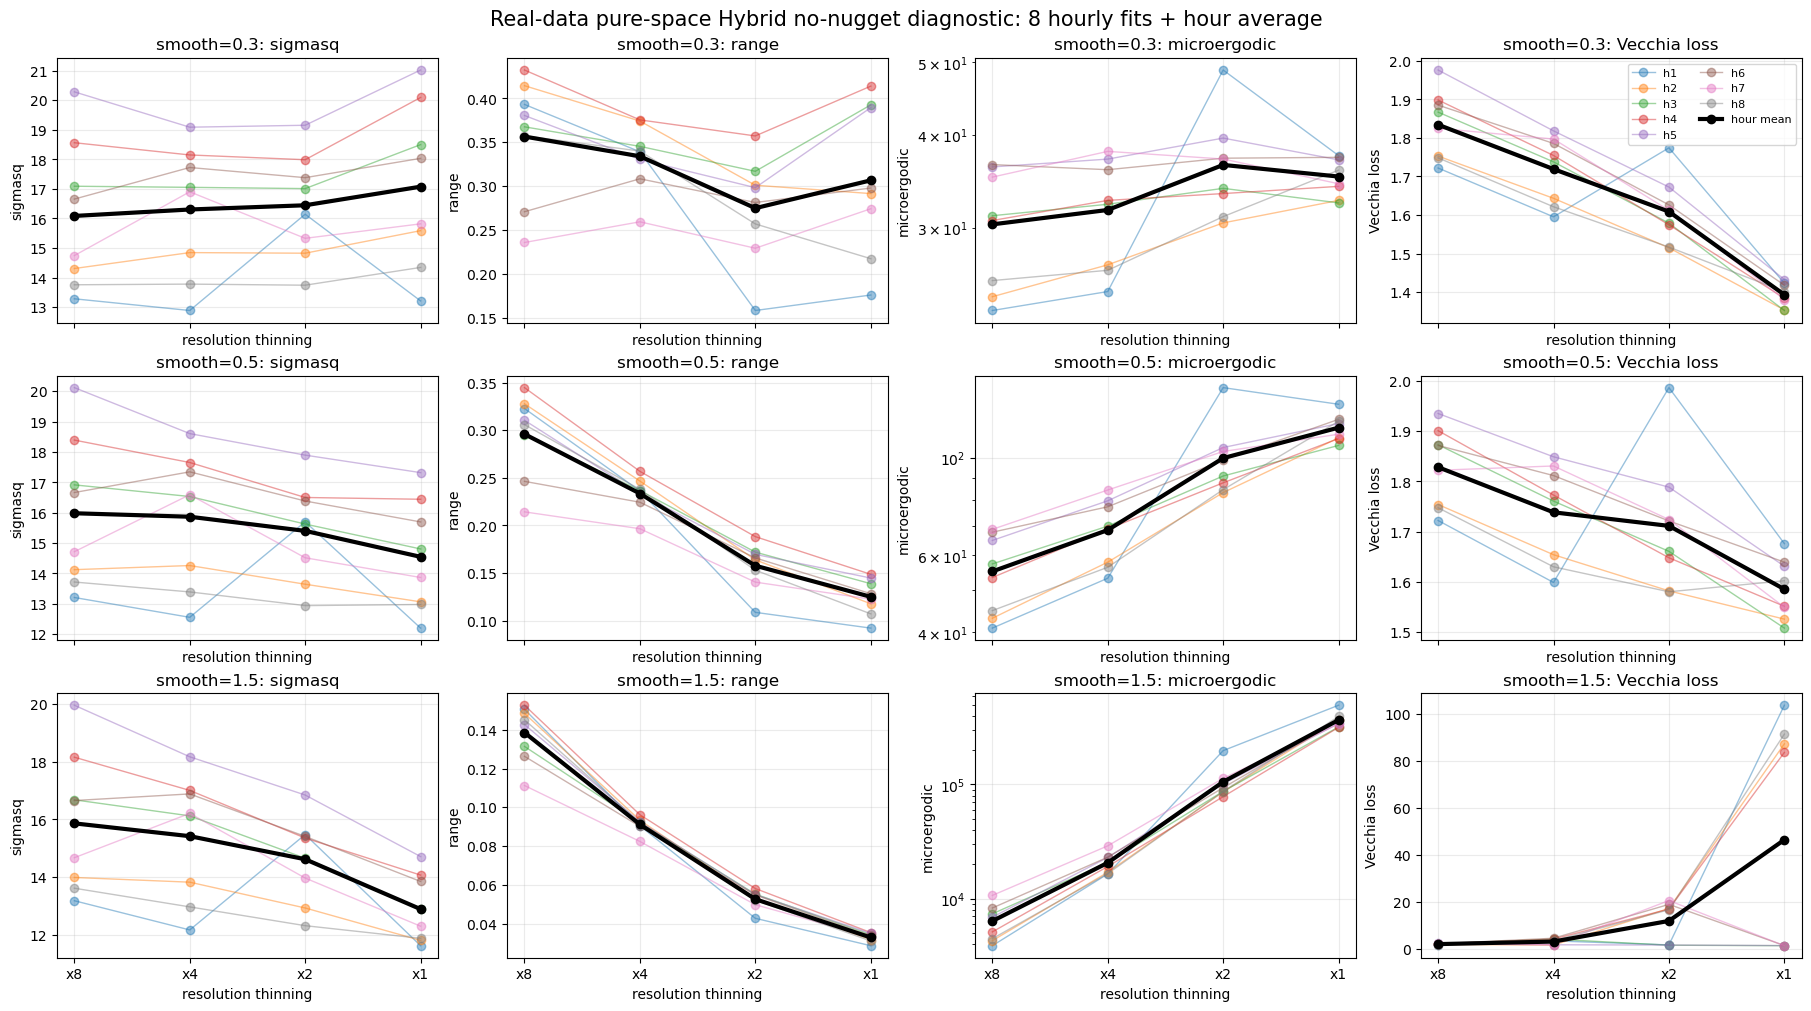

In [9]:
# Parameter trajectories: thin lines are individual hours, thick black line is average across hours.
params = [
    ('est_sigmasq', 'sigmasq'),
    ('est_range', 'range'),
    ('est_microergodic', 'microergodic'),
    ('loss', 'Vecchia loss'),
]

fig, axes = plt.subplots(len(FIT_SMOOTHS), len(params), figsize=(18, 10), constrained_layout=True, sharex=True)
for i, smooth in enumerate(FIT_SMOOTHS):
    sub_s = plot_df[plot_df['smooth'] == smooth].copy()
    for j, (col, label) in enumerate(params):
        ax = axes[i, j]
        for hour_idx, hs in sub_s.groupby('hour_idx'):
            hs = hs.sort_values('resolution_label')
            ax.plot(hs['resolution_label'].astype(str), hs[col], marker='o', linewidth=1.0, alpha=0.45, label=f'h{int(hour_idx)+1}')
        mean_s = (
            sub_s
            .groupby('resolution_label', observed=False)[col]
            .mean()
            .reindex([f'x{s}' for s in RESOLUTION_STRIDES])
        )
        ax.plot(mean_s.index.astype(str), mean_s.values, color='black', marker='o', linewidth=3.0, label='hour mean')
        ax.set_title(f'smooth={smooth}: {label}')
        ax.set_xlabel('resolution thinning')
        ax.set_ylabel(label)
        if col == 'est_microergodic':
            ax.set_yscale('log')
        ax.grid(True, alpha=0.25)
        if i == 0 and j == len(params) - 1:
            ax.legend(fontsize=8, ncols=2)

fig.suptitle('Real-data pure-space Hybrid no-nugget diagnostic: 8 hourly fits + hour average', fontsize=15)
plot_path = OUT_DIR / f'{OUT_PREFIX}_param_trajectories_with_hour_mean.png'
fig.savefig(plot_path, dpi=180, bbox_inches='tight')
print('Saved trajectory plot:', plot_path)
plt.show()


Saved average plot: /Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/local_computer/pure_space/log/real_pure_space_nugget0_smooth_diagnostic_hybrid_050826_hour_average_by_smooth.png


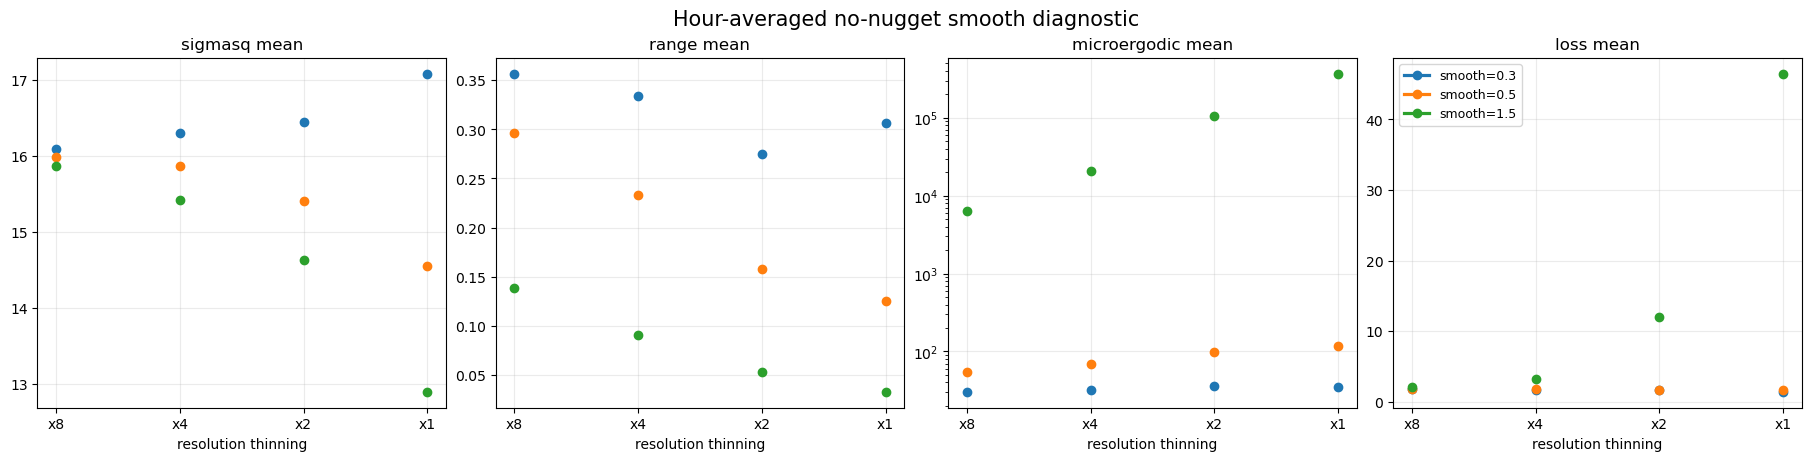

In [10]:
# Average-only plot for cleaner comparison across smooth values.
avg_plot = avg_df.copy()
avg_plot['resolution_label'] = pd.Categorical(
    avg_plot['resolution_label'], categories=[f'x{s}' for s in RESOLUTION_STRIDES], ordered=True
)

avg_specs = [
    ('sigmasq_mean', 'sigmasq mean'),
    ('range_mean', 'range mean'),
    ('microergodic_mean', 'microergodic mean'),
    ('loss_mean', 'loss mean'),
]

fig, axes = plt.subplots(1, len(avg_specs), figsize=(18, 4.5), constrained_layout=True)
for ax, (col, label) in zip(axes, avg_specs):
    for smooth, ss in avg_plot.groupby('smooth'):
        ss = ss.sort_values('resolution_label')
        ax.plot(ss['resolution_label'].astype(str), ss[col], marker='o', linewidth=2.3, label=f'smooth={smooth}')
    if col == 'microergodic_mean':
        ax.set_yscale('log')
    ax.set_title(label)
    ax.set_xlabel('resolution thinning')
    ax.grid(True, alpha=0.25)
axes[-1].legend(fontsize=9)
fig.suptitle('Hour-averaged no-nugget smooth diagnostic', fontsize=15)
avg_plot_path = OUT_DIR / f'{OUT_PREFIX}_hour_average_by_smooth.png'
fig.savefig(avg_plot_path, dpi=180, bbox_inches='tight')
print('Saved average plot:', avg_plot_path)
plt.show()


## Fitted-vs-data spectrum diagnostic

This section compares the empirical detrended residual spectrum with the fitted no-nugget Matérn spectrum.

For each hour and resolution:

1. refit results provide `smooth`, `sigmasq`, and `range`;
2. residuals are computed by an OLS `intercept + lat + lon` detrend on the same thinned points;
3. residuals are placed back on the full grid, tapered, zero-filled, FFTed, and radially averaged;
4. the fitted theoretical Matérn spectrum is evaluated on the full-grid radial frequency axis.

The empirical data spectrum is shown only up to the effective Nyquist frequency for each thinning level; the theoretical curve is kept on the full-grid axis. The theoretical spectrum is scaled to the empirical curve on the overlapping low-frequency support, so this is a shape diagnostic rather than an exact Whittle likelihood.


In [11]:
# Fitted-vs-data spectrum diagnostic.
if 'fit_df' not in globals() or fit_df.empty:
    fit_df = pd.read_csv(OUT_DIR / f'{OUT_PREFIX}_fits.csv')

RADIAL_N_BINS = 70
RADIAL_QMAX = 0.985
APPLY_HANN = True
EPS = 1e-12

N_LAT, N_LON = len(lat_vals), len(lon_vals)
LAT_STEP = float(np.median(np.diff(lat_vals))) if N_LAT > 1 else 1.0
LON_STEP = float(np.median(np.diff(lon_vals))) if N_LON > 1 else 1.0
print('spectral full grid:', (N_LAT, N_LON), 'lat/lon step:', LAT_STEP, LON_STEP)


def detrended_residual_grid(hour_idx, stride):
    hour_map, time_key = load_hour_map(hour_idx)
    thin_map, thin_grid, thin_idx = thin_hour_map(hour_map, stride)
    arr = next(iter(thin_map.values())).detach().cpu().numpy()
    y = arr[:, 2].astype(float)
    lat = arr[:, 0].astype(float)
    lon = arr[:, 1].astype(float)
    valid = np.isfinite(y) & np.isfinite(lat) & np.isfinite(lon)

    grid = np.zeros((N_LAT, N_LON), dtype=float)
    mask = np.zeros((N_LAT, N_LON), dtype=float)
    if valid.sum() < 4:
        return grid, mask, time_key, int(valid.sum())

    X = np.column_stack([np.ones(valid.sum()), lat[valid], lon[valid]])
    beta, *_ = np.linalg.lstsq(X, y[valid], rcond=None)
    resid = y[valid] - X @ beta
    resid = resid - np.nanmean(resid)

    rows = grid_row[thin_idx][valid]
    cols = grid_col[thin_idx][valid]
    grid[rows, cols] = resid
    mask[rows, cols] = 1.0
    return grid, mask, time_key, int(valid.sum())


def masked_periodogram(grid, mask):
    x = np.asarray(grid, dtype=float)
    m = np.asarray(mask, dtype=float)
    x = np.where(np.isfinite(x), x, 0.0)
    if m.sum() > 0:
        x = x - (x * m).sum() / max(m.sum(), 1.0)
    x = x * m
    if APPLY_HANN:
        win = np.outer(np.hanning(N_LAT), np.hanning(N_LON))
        x = x * win
        norm = np.sum((m * win) ** 2)
    else:
        norm = np.sum(m)
    norm = max(float(norm), 1.0)
    fft = np.fft.fft2(x)
    p = (np.abs(fft) ** 2) / norm
    return np.fft.fftshift(p)


freq_lat = np.fft.fftshift(np.fft.fftfreq(N_LAT, d=LAT_STEP))
freq_lon = np.fft.fftshift(np.fft.fftfreq(N_LON, d=LON_STEP))
Q_LAT, Q_LON = np.meshgrid(freq_lat, freq_lon, indexing='ij')
K_RAD = np.sqrt(Q_LAT ** 2 + Q_LON ** 2)
K_MAX = float(np.quantile(K_RAD.reshape(-1), RADIAL_QMAX))
BIN_EDGES = np.linspace(0.0, K_MAX, RADIAL_N_BINS + 1)
BIN_ID = np.digitize(K_RAD.reshape(-1), BIN_EDGES, right=False) - 1


def radial_average(power):
    p = np.asarray(power, dtype=float).reshape(-1)
    rows = []
    for b in range(RADIAL_N_BINS):
        use = (BIN_ID == b) & np.isfinite(p)
        if not use.any():
            continue
        rows.append({
            'k_bin': int(b),
            'k_mid': float(0.5 * (BIN_EDGES[b] + BIN_EDGES[b + 1])),
            'spectrum': float(np.mean(p[use])),
            'n_freq': int(use.sum()),
        })
    return pd.DataFrame(rows)


def matern_spectrum_shape(sigmasq, range_, smooth):
    # Shape of d-dimensional Matern spectrum under length-scale range.
    # The multiplicative constant is not used; the curve is scaled to empirical power.
    nu = float(smooth)
    d = 2.0
    ell = float(range_)
    q2 = Q_LAT ** 2 + Q_LON ** 2
    return float(sigmasq) * (ell ** d) * (1.0 + (2.0 * np.pi * ell) ** 2 * q2 / max(2.0 * nu, EPS)) ** (-(nu + d / 2.0))


spectral_rows = []
for r in fit_df.itertuples(index=False):
    grid, mask, time_key, n_valid_spectrum = detrended_residual_grid(int(r.hour_idx), int(r.resolution_stride))
    data_p = masked_periodogram(grid, mask)
    theory_p = matern_spectrum_shape(r.est_sigmasq, r.est_range, r.smooth)

    data_rad = radial_average(data_p).rename(columns={'spectrum': 'data_spectrum'})
    theory_rad = radial_average(theory_p).rename(columns={'spectrum': 'theory_spectrum'})
    merged = data_rad.merge(theory_rad[['k_bin', 'theory_spectrum']], on='k_bin', how='inner')

    full_k_max = float(merged['k_mid'].max())
    effective_k_max = full_k_max / float(r.resolution_stride)
    overlap = merged['k_mid'].to_numpy(dtype=float) <= effective_k_max
    d = merged['data_spectrum'].to_numpy(dtype=float)
    t = merged['theory_spectrum'].to_numpy(dtype=float)
    good = overlap & np.isfinite(d) & np.isfinite(t) & (d > 0) & (t > 0)
    scale = float(np.exp(np.mean(np.log(d[good]) - np.log(t[good])))) if good.any() else 1.0
    merged['theory_spectrum_scaled'] = merged['theory_spectrum'] * scale

    for mrow in merged.itertuples(index=False):
        spectral_rows.append({
            'date_str': str(r.date_str),
            'hour_idx': int(r.hour_idx),
            'time_key': time_key,
            'smooth': float(r.smooth),
            'resolution_stride': int(r.resolution_stride),
            'resolution_label': str(r.resolution_label),
            'n_valid_spectrum': int(n_valid_spectrum),
            'est_sigmasq': float(r.est_sigmasq),
            'est_range': float(r.est_range),
            'est_nugget': 0.0,
            'k_bin': int(mrow.k_bin),
            'k_mid': float(mrow.k_mid),
            'n_freq': int(mrow.n_freq),
            'effective_k_max': float(effective_k_max),
            'data_spectrum': float(mrow.data_spectrum),
            'theory_spectrum_raw': float(mrow.theory_spectrum),
            'theory_spectrum_scaled': float(mrow.theory_spectrum_scaled),
            'theory_scale_to_data': float(scale),
        })

spectral_df = pd.DataFrame(spectral_rows)
spectral_path = OUT_DIR / f'{OUT_PREFIX}_radial_spectrum.csv'
spectral_df.to_csv(spectral_path, index=False)
print('Saved radial spectrum:', spectral_path)
display(round_df(spectral_df.head(12)))


spectral full grid: (114, 159) lat/lon step: 0.04400000000000004 0.06300000000000239
Saved radial spectrum: /Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/local_computer/pure_space/log/real_pure_space_nugget0_smooth_diagnostic_hybrid_050826_radial_spectrum.csv


,date_str,hour_idx,time_key,smooth,resolution_stride,resolution_label,n_valid_spectrum,est_sigmasq,est_range,est_nugget,k_bin,k_mid,n_freq,effective_k_max,data_spectrum,theory_spectrum_raw,theory_spectrum_scaled,theory_scale_to_data
0,20240703,0,2024_07_y24m07day03_hm00:53,0.3,8,x8,300,13.283,0.3931,0.0,0,0.0912,3,1.5843,21.7271,1.8911,134.2023,70.9654
1,20240703,0,2024_07_y24m07day03_hm00:53,0.3,8,x8,300,13.283,0.3931,0.0,1,0.2735,18,1.5843,76.3806,1.0235,72.6318,70.9654
2,20240703,0,2024_07_y24m07day03_hm00:53,0.3,8,x8,300,13.283,0.3931,0.0,2,0.4559,26,1.5843,17.6118,0.4714,33.4506,70.9654
3,20240703,0,2024_07_y24m07day03_hm00:53,0.3,8,x8,300,13.283,0.3931,0.0,3,0.6383,42,1.5843,8.1336,0.2375,16.8552,70.9654
4,20240703,0,2024_07_y24m07day03_hm00:53,0.3,8,x8,300,13.283,0.3931,0.0,4,0.8206,42,1.5843,9.6322,0.1367,9.7006,70.9654
5,20240703,0,2024_07_y24m07day03_hm00:53,0.3,8,x8,300,13.283,0.3931,0.0,5,1.0030,60,1.5843,7.1742,0.0883,6.2654,70.9654
6,20240703,0,2024_07_y24m07day03_hm00:53,0.3,8,x8,300,13.283,0.3931,0.0,6,1.1853,66,1.5843,9.1973,0.0590,4.1839,70.9654
7,20240703,0,2024_07_y24m07day03_hm00:53,0.3,8,x8,300,13.283,0.3931,0.0,7,1.3677,86,1.5843,8.1513,0.0413,2.9343,70.9654
8,20240703,0,2024_07_y24m07day03_hm00:53,0.3,8,x8,300,13.283,0.3931,0.0,8,1.5501,86,1.5843,7.0925,0.0300,2.1301,70.9654
9,20240703,0,2024_07_y24m07day03_hm00:53,0.3,8,x8,300,13.283,0.3931,0.0,9,1.7324,98,1.5843,19.1420,0.0230,1.6310,70.9654


Saved averaged spectrum: /Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/local_computer/pure_space/log/real_pure_space_nugget0_smooth_diagnostic_hybrid_050826_radial_spectrum_hour_average.csv
Saved spectrum plot: /Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/local_computer/pure_space/log/real_pure_space_nugget0_smooth_diagnostic_hybrid_050826_data_vs_fitted_spectrum.png


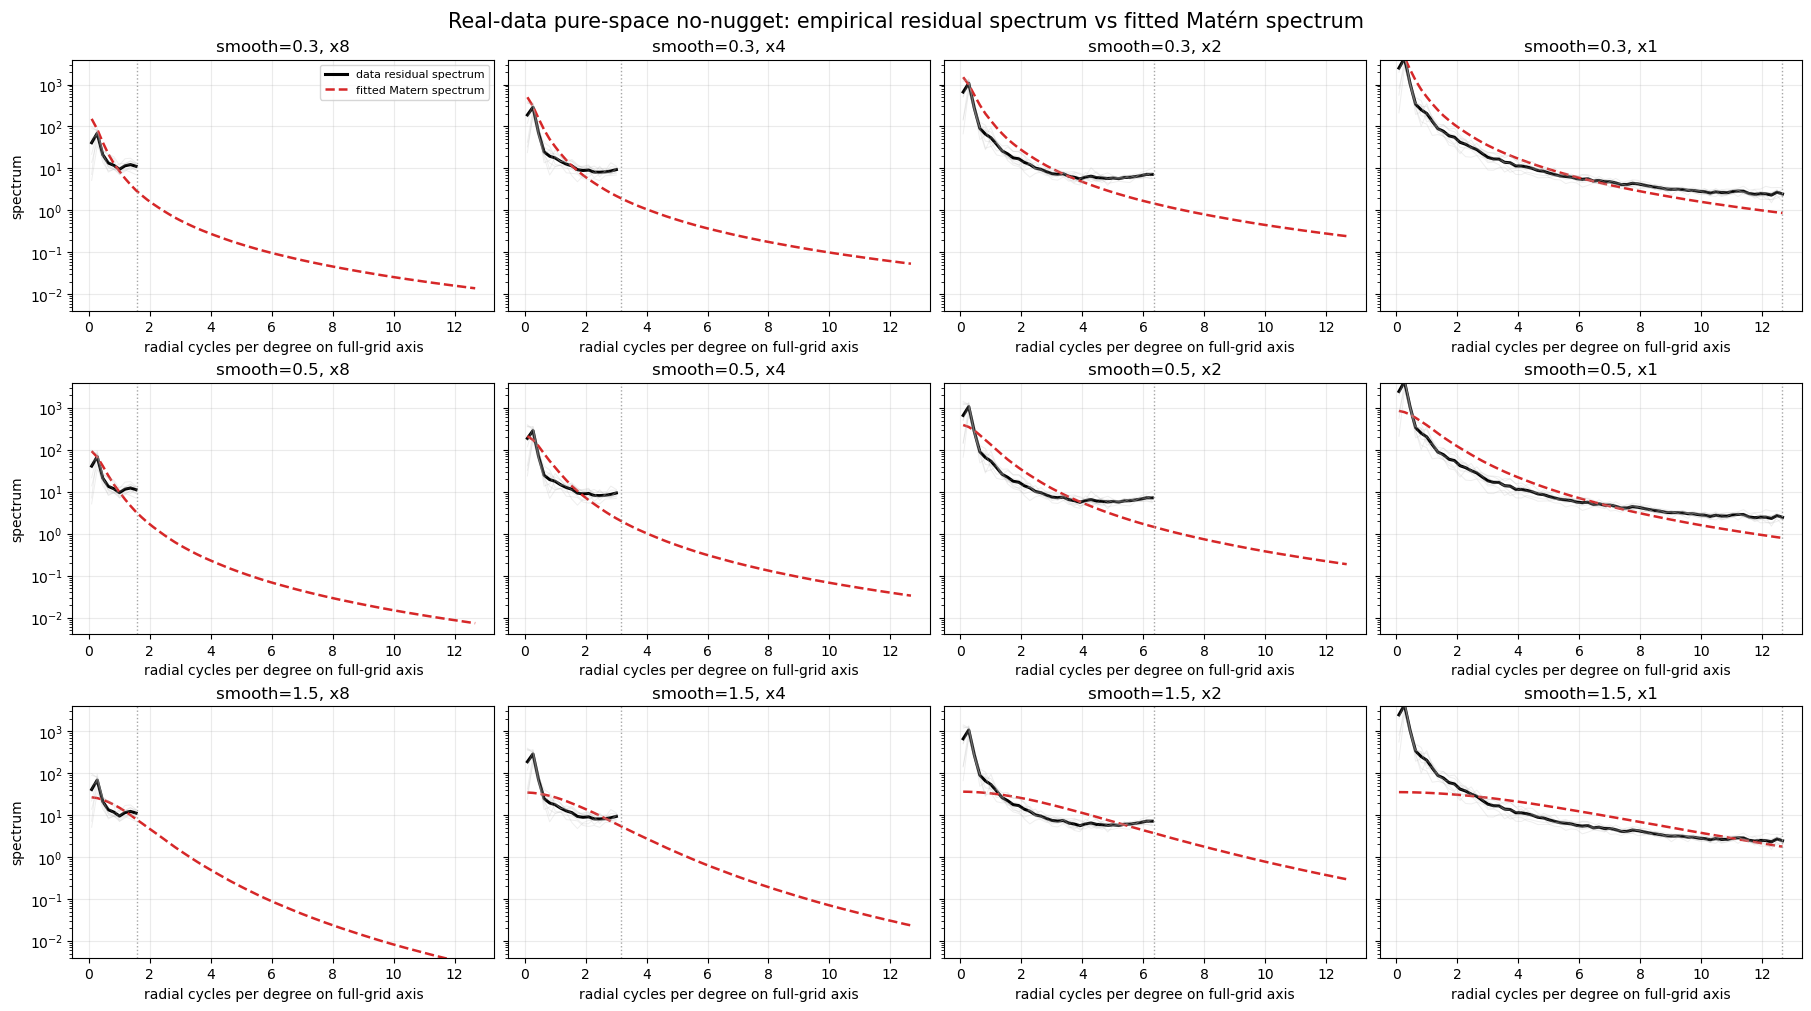

In [12]:
# Plot average fitted-vs-data spectra: rows=smooth, columns=resolution.
if 'spectral_df' not in globals() or spectral_df.empty:
    spectral_df = pd.read_csv(OUT_DIR / f'{OUT_PREFIX}_radial_spectrum.csv')

plot_spec = spectral_df.copy()
plot_spec['resolution_label'] = pd.Categorical(
    plot_spec['resolution_label'], categories=[f'x{s}' for s in RESOLUTION_STRIDES], ordered=True
)

avg_spec = (
    plot_spec
    .groupby(['smooth', 'resolution_stride', 'resolution_label', 'k_bin'], observed=False)
    .agg(
        k_mid=('k_mid', 'mean'),
        effective_k_max=('effective_k_max', 'mean'),
        data_spectrum=('data_spectrum', 'mean'),
        theory_spectrum_scaled=('theory_spectrum_scaled', 'mean'),
        n_hours=('hour_idx', 'nunique'),
    )
    .reset_index()
)
avg_spec_path = OUT_DIR / f'{OUT_PREFIX}_radial_spectrum_hour_average.csv'
avg_spec.to_csv(avg_spec_path, index=False)
print('Saved averaged spectrum:', avg_spec_path)

smooth_order = list(FIT_SMOOTHS)
labels_order = [f'x{s}' for s in RESOLUTION_STRIDES]
fig, axes = plt.subplots(len(smooth_order), len(labels_order), figsize=(18, 10), constrained_layout=True, sharey='row')

positive_vals = []
for _, row in avg_spec.iterrows():
    if np.isfinite(row['data_spectrum']) and row['data_spectrum'] > 0:
        positive_vals.append(row['data_spectrum'])
    if np.isfinite(row['theory_spectrum_scaled']) and row['theory_spectrum_scaled'] > 0:
        positive_vals.append(row['theory_spectrum_scaled'])
ymin = max(np.nanpercentile(positive_vals, 1) * 0.5, 1e-6) if positive_vals else 1e-3
ymax = np.nanpercentile(positive_vals, 99.5) * 2.0 if positive_vals else 1e3

for i, smooth in enumerate(smooth_order):
    for j, label in enumerate(labels_order):
        ax = axes[i, j]
        sub = avg_spec[(avg_spec['smooth'] == smooth) & (avg_spec['resolution_label'].astype(str) == label)].copy()
        if sub.empty:
            ax.set_visible(False)
            continue
        sub = sub[sub['k_mid'] > 0].sort_values('k_mid')
        k_cut = float(sub['effective_k_max'].iloc[0])
        data_sub = sub[sub['k_mid'] <= k_cut]
        ax.plot(data_sub['k_mid'], data_sub['data_spectrum'], color='black', linewidth=2.2, label='data residual spectrum')
        ax.plot(sub['k_mid'], sub['theory_spectrum_scaled'], color='tab:red', linewidth=1.8, linestyle='--', label='fitted Matern spectrum')

        hour_sub = plot_spec[
            (plot_spec['smooth'] == smooth)
            & (plot_spec['resolution_label'].astype(str) == label)
            & (plot_spec['k_mid'] > 0)
        ].copy()
        for _, hs in hour_sub.groupby('hour_idx'):
            hs = hs[hs['k_mid'] <= hs['effective_k_max']].sort_values('k_mid')
            ax.plot(hs['k_mid'], hs['data_spectrum'], color='0.7', alpha=0.22, linewidth=0.7)

        ax.axvline(k_cut, color='0.65', linestyle=':', linewidth=1.0)
        ax.set_title(f'smooth={smooth}, {label}')
        ax.set_xlabel('radial cycles per degree on full-grid axis')
        if j == 0:
            ax.set_ylabel('spectrum')
        ax.set_yscale('log')
        ax.set_ylim(ymin, ymax)
        ax.grid(True, alpha=0.25)

axes[0, 0].legend(fontsize=8)
fig.suptitle('Real-data pure-space no-nugget: empirical residual spectrum vs fitted Matérn spectrum', fontsize=15)
spectrum_plot_path = OUT_DIR / f'{OUT_PREFIX}_data_vs_fitted_spectrum.png'
fig.savefig(spectrum_plot_path, dpi=180, bbox_inches='tight')
print('Saved spectrum plot:', spectrum_plot_path)
plt.show()
